# Deconvolve Chromatin Bins for CLB2

In this notebook, we will be refactoring the creation of the H matrix for the RG1 model. For Yulong's dataset, we have alpha factor arrested cells that go through recovery. We want this recovery period to incorporate the first G1, so the initial branch will be: Recovery - postG1. The calcH needs to be updated to reflect that change.

Goal:
- Refactor the creation of the H matrix
- We need to make changes to add the RG1 logic (merge R and G1 for the first c for {0, 0}

Steps:
1. Plot the growth curve to better understand the existing calc H function

In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
from src.config import load_yl_replicate2_rg1_config, \
    load_xg_gene_expression_config
from src.model import Model

gene_name = 'CLB2'

# We will load the configuration and model for the gene.
# Note this is still for the gene expression configuration.
# We are most interested in the H matrix.
config = load_yl_replicate2_rg1_config()
model = Model(config, gene_name, 0.004)
print("The shape of the convolution kernel matrix, H is: ", model.H.shape)

The shape of the convolution kernel matrix, H is:  (14, 226)


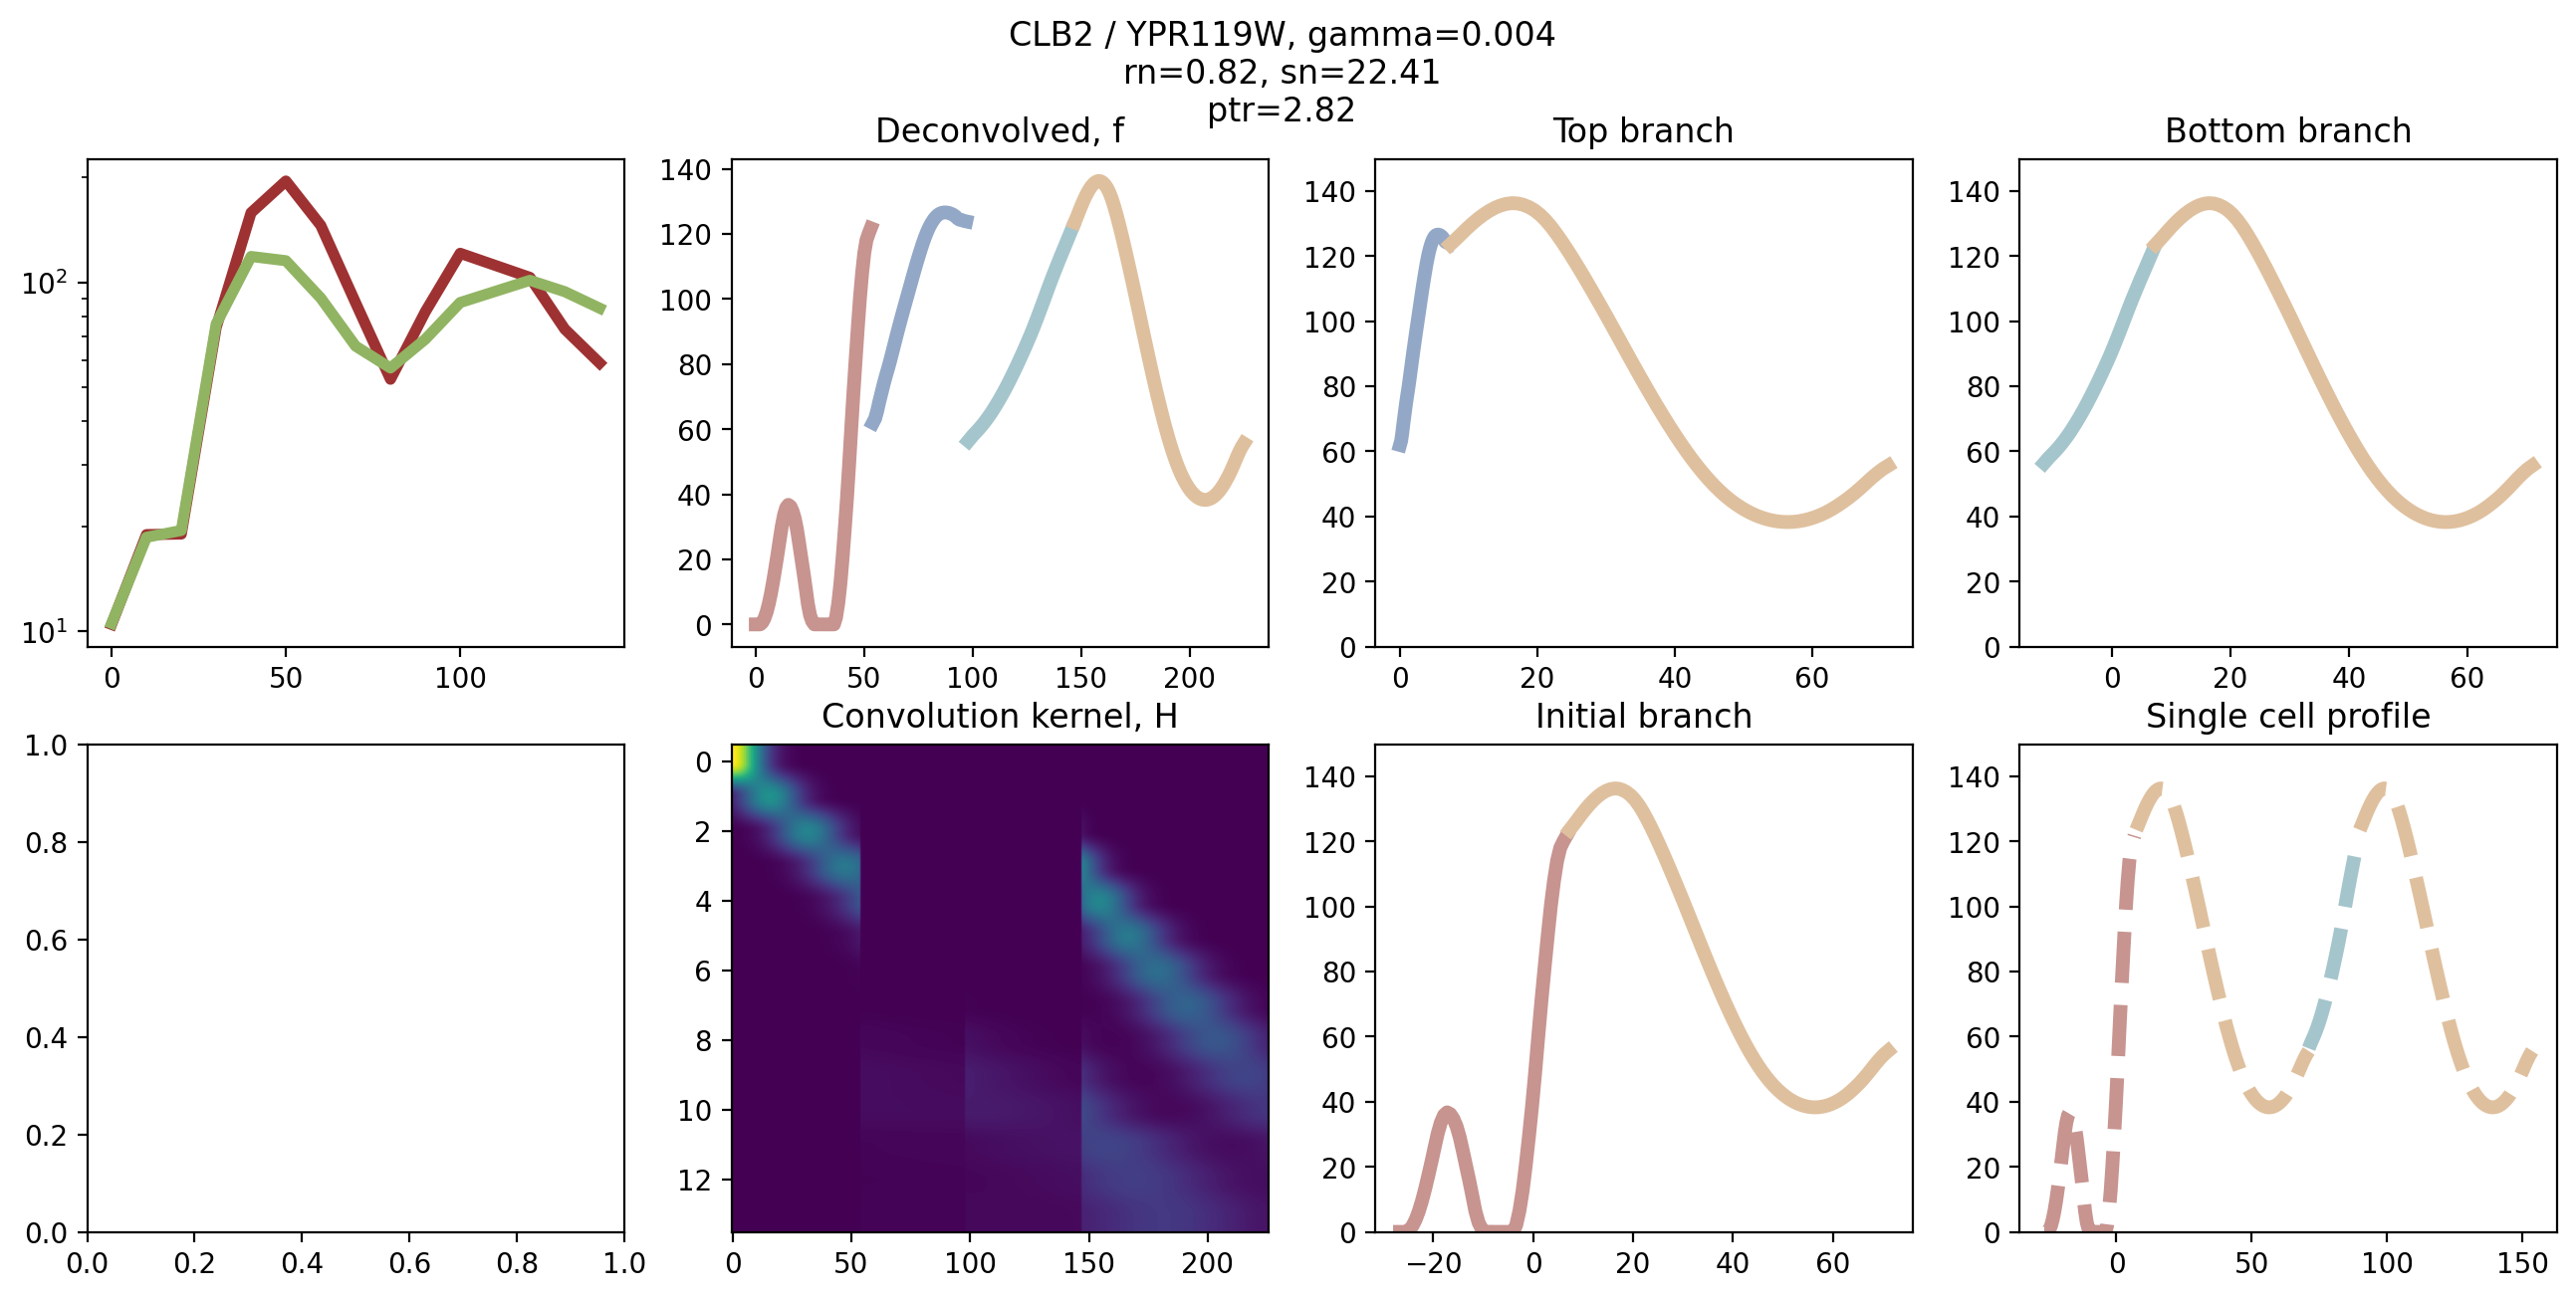

In [9]:
model.deconvolve()
model.plot_deconvolved_gene()

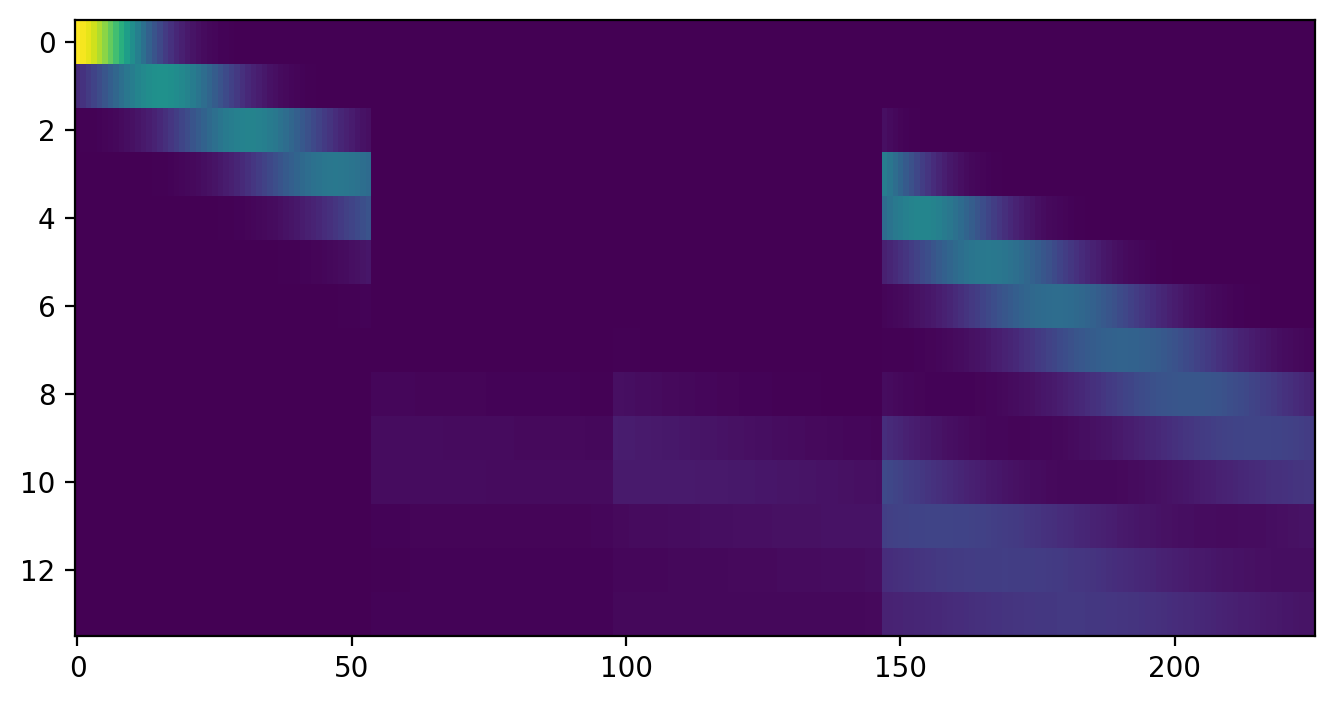

In [12]:
plt.figure(figsize=(8, 4))
plt.imshow(model.H, aspect='auto')

In [16]:
H = model.H

In [210]:
def plot_phase_stack(tp, prev_vec, cur_vec, name):
    from src.model import color_for_key

    if prev_vec is None:
        prev_vec = np.zeros_like(cur_vec)
    
    cur_stack = prev_vec+cur_vec
    
    plt.fill_between(tp, prev_vec, cur_stack, color=color_for_key(name), label=name)

    return cur_stack

    
def plot_H_as_growth_curve(model):
    
    H = model.H
    tp = model.config.WT1_TIMEPOINTS
    phase_columns = model.config.phase_columns
    keys = list(phase_columns.keys())

    plt.figure(figsize=(6, 4))
    plt.ylim(0, 2.)

    for i in range(len(keys)):
        key = keys[i]

        if i == 0:
            previous_stack = None
    
        cur_columns = phase_columns[key]
        cur_vector = H[:, cur_columns].sum(axis=1)

        previous_stack = plot_phase_stack(tp, prev_vec=previous_stack, cur_vec=cur_vector, 
                                         name=key)

    plt.legend()

def plot_H_as_growth_curve(model):
    
    H = model.H
    tp = model.config.WT1_TIMEPOINTS
    phase_columns = model.config.phase_columns
    keys = list(phase_columns.keys())

    plt.figure(figsize=(6, 4))
    plt.ylim(0, 2.)

    phases = []
    vectors = []

    for phase, indices in phase_columns.items():
        cur_vec = H[:, indices].sum(axis=1)
        vectors.append(cur_vec)
        phases.append(phase)
        
    plot_stacked_curves(tp, vectors, phases)

    plt.legend()

def plot_stacked_curves(x, vectors, names):
    
    for i in range(len(vectors)):

        if i == 0:
            previous_stack = None
    
        cur_vector = vectors[i]
        name = names[i]

        previous_stack = plot_phase_stack(x, prev_vec=previous_stack, 
                                          cur_vec=cur_vector, name=name)
    

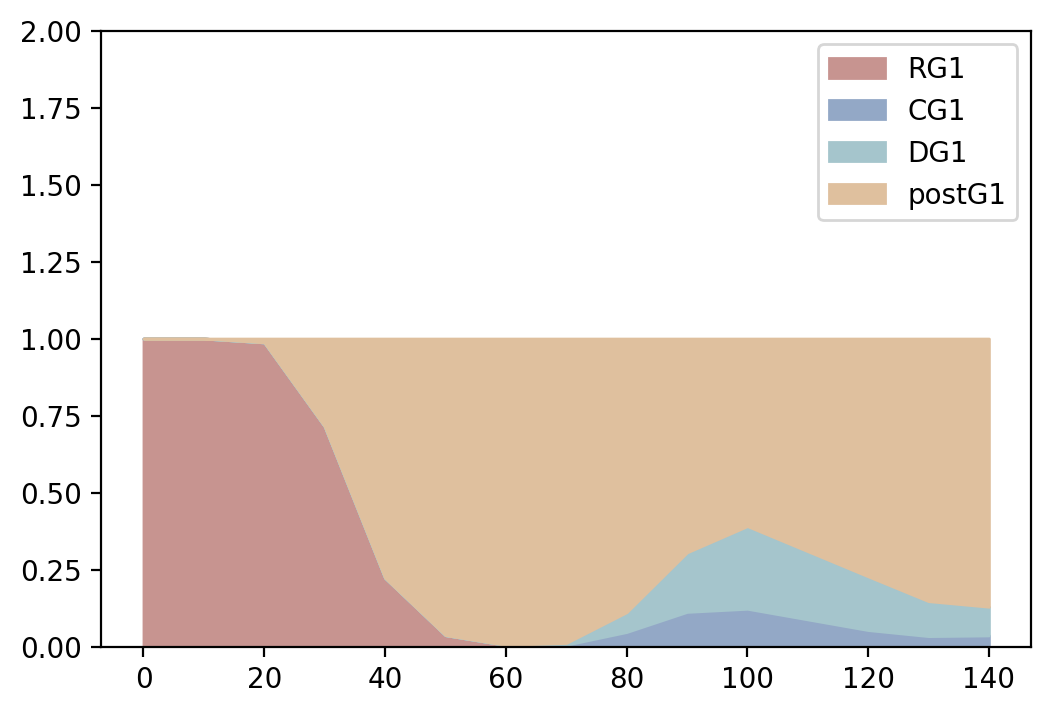

In [211]:
plot_H_as_growth_curve(model)

In [91]:
# Let's try and reproduce the growth curves as written in java.

In [98]:
from cc_src.model_mass_calculator import MassCalculator

mass_calc = MassCalculator()

In [152]:
[mass_g1, mass_s, mass_g2, 
 mass_r, mass_cg1, mass_dg1] = mass_calc.get_cell_cycle_subinterval_mass(0, 0, 0)
mass_r

0.9857610534224224

In [156]:
from cc_src.model_mass_calculator import MaxNumCellCycles

def compute_subinterval_mass(time):

    g1Proportion = 0.0
    g2Proportion = 0.0
    sProportion = 0.0
    rProportion = 0.0
    cg1Proportion = 0.0
    dg1Proportion = 0.0

    for g in range(MaxNumCellCycles + 1):
        for r in range(g, MaxNumCellCycles + 1):
            cohort_masses = mass_calc.get_cell_cycle_subinterval_mass(time, g, r)

            g1Proportion += cohort_masses[0]
            sProportion += cohort_masses[1]
            g2Proportion += cohort_masses[2]

            rProportion += cohort_masses[3]
            cg1Proportion += cohort_masses[4]
            dg1Proportion += cohort_masses[5]

    total_intervals_sum = g1Proportion + sProportion + g2Proportion
    g1Proportion /= total_intervals_sum
    sProportion /= total_intervals_sum
    g2Proportion /= total_intervals_sum

    total_g1_proportion = g1Proportion / (rProportion + cg1Proportion + dg1Proportion)
    rProportion *= total_g1_proportion
    cg1Proportion *= total_g1_proportion
    dg1Proportion *= total_g1_proportion

    return total_g1_proportion, rProportion, cg1Proportion, dg1Proportion, \
            sProportion, g2Proportion


In [157]:
timepoints = model.config.WT1_TIMEPOINTS

all_total_g1_proportion = []
all_rProportion = []
all_cg1Proportion = []
all_dg1Proportion = []
all_sProportion = []
all_g2Proportion = []

for time in timepoints:
    (total_g1_proportion, rProportion, cg1Proportion, dg1Proportion, \
            sProportion, g2Proportion) = compute_subinterval_mass(time)

    all_total_g1_proportion.append(total_g1_proportion)
    all_rProportion.append(rProportion)
    all_cg1Proportion.append(cg1Proportion)
    all_dg1Proportion.append(dg1Proportion)
    all_sProportion.append(sProportion)
    all_g2Proportion.append(g2Proportion)


In [160]:
sub_mass_df = pd.DataFrame({
    'time': timepoints,
    'total_g1': all_total_g1_proportion,
             'R': all_rProportion,
             'CG1': all_cg1Proportion,
             'DG1': all_dg1Proportion,
             'S': all_sProportion,
             'G2': all_g2Proportion})

In [161]:
sub_mass_df.head(3)


,time,total_g1,R,CG1,DG1,S,G2
0,0,1.0,0.985761,3.974798e-11,9.995560e-12,0.013962,0.000277
1,10,1.0,0.936683,3.249457e-09,7.365755e-10,0.060627,0.002690
2,20,1.0,0.805753,2.169204e-07,4.308051e-08,0.176291,0.017955


In [219]:
def plot_subinterval_mass_port(sub_mass_df):
    
    tp = sub_mass_df.time
    phase_columns = sub_mass_df.columns[2:]

    plt.figure(figsize=(6, 4))
    plt.ylim(0, 2.)

    vectors = []

    for phase in phase_columns:
        cur_vec = sub_mass_df[phase]
        vectors.append(cur_vec)
        
    plot_stacked_curves(tp, vectors, phase_columns)

    plt.legend()

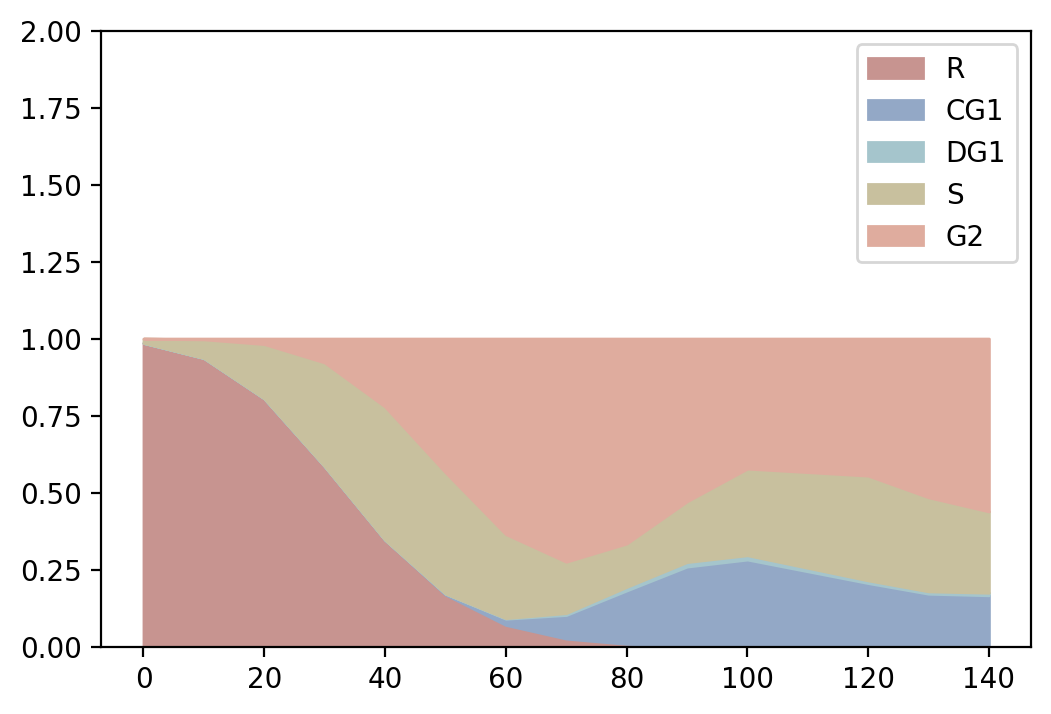

In [220]:
plot_subinterval_mass_port(sub_mass_df)